In [20]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import defaultdict
from scipy.stats import pearsonr, norm
import numpy as np

import scienceplots

In [21]:
DARK_BLUE  = (0.0, 0.4667, 0.7333)
LIGHT_BLUE = (0.2, 0.7333, 0.9333)
GREEN      = (0.0, 0.6, 0.5333)
ORANGE     = (0.9333, 0.4667, 0.2)
RED        = (0.8, 0.2, 0.0667)
PINK       = (0.9333, 0.2, 0.4667)
GRAY       = (0.7333, 0.7333, 0.7333)

SAVE = True

In [22]:
N_TRIALS = 80
T_INIT = 300
DT = 0.1
DT_RECORD = 10
N_NEURONS = 400

In [23]:
def load_data(folder):
    data = {}
    for trial in range(N_TRIALS):
        data[trial] = {}
        
        for file in os.listdir(folder):
            file_name = os.path.join(folder, file)
            
            if f"_{trial}_initial_weights.csv" in file:
                loaded_data = np.genfromtxt(file_name, delimiter=',', names=True, dtype=None, encoding='utf-8')
                N = loaded_data['post'].max()+1
                W = np.zeros((N, N), dtype=float)
                for pre, post, w in loaded_data:
                    W[pre, post] = w
                data[trial]['ws_init'] = W
                data[trial]['ws_init_list'] = loaded_data
                
            if f"_{trial}_final_weights.csv" in file:
                loaded_data = np.genfromtxt(file_name, delimiter=',', names=True, dtype=None, encoding='utf-8')
                N = loaded_data['post'].max()+1
                W = np.zeros((N, N), dtype=float)
                for pre, post, w in loaded_data:
                    W[pre, post] = w
                data[trial]['ws_final'] = W
                data[trial]['ws_final_list'] = loaded_data
                
            if f"_{trial}_neuron_ids" in file:
                with open(file_name, "r") as f:
                    neuron_ids = json.load(f)
                    data[trial]['ids'] = neuron_ids
                    
            if f"_{trial}_results.csv" in file:
                with open(file_name, "r") as f:
                    results = np.loadtxt(f)
                    data[trial]['s_acc'] = np.mean(results[:50])
                    data[trial]['e_acc'] = np.mean(results[-50:])
                    
    return data

In [24]:
folder_fb = '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/FB/02_23_22_49_LR_1_PW_04_HigherDeltaBCM_30_17_15_4'
folder_nfb = '/Users/juliuswuerzler/Desktop/Results_Thesis/NoFb'

baseline_folder = '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/2_Dropout/02_24_21_46_LR_1_PW_04_Dropout_HigherDeltaBCM_DropoutBaseline'

data = {}
data_nfb = {}

data = load_data(folder_fb)
data_nfb = load_data(folder_nfb)

In [25]:
baseline_path = '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/PreTrainingBaseline/summary.json'
with open(baseline_path, 'r') as f:
    baseline_data = json.load(f)
results = np.array(baseline_data["results"])

In [26]:
K_PER_ELECTRODE = 3
N_ELECTRODES = 8
N=400
N_ORDERS = 3
stim_regions = [x for x in range(N_ELECTRODES)]
post_regions = ["U", "D", "R"]
phases = ["init", "final"]


for i in range(N_TRIALS):
    d = data[i]
    d['plot_data'] = {}
    
    # pre_ids = d['ws_init']['pre']
    # post_ids = d['ws_init']['post']
    
    for stim_region in stim_regions:
        d['plot_data'][stim_region] = {}
        
        for post_region in post_regions:
            d['plot_data'][stim_region][post_region] = {}
            
            pre_mask = d['ids']['stimulation_ids'][stim_region*K_PER_ELECTRODE:(stim_region+1)*K_PER_ELECTRODE]#np.isin(pre_ids, d['ids']['stimulation_ids'][stim_region*K_PER_ELECTRODE:(stim_region+1)*K_PER_ELECTRODE])

            post_mask = np.array([])
            if post_region != "R":
                post_mask = d['ids'][f'motor_ids_{post_region}']
            else:
                post_mask = np.setdiff1d(np.arange(N), np.hstack((d['ids'][f'motor_ids_U'],  d['ids'][f'motor_ids_D'])))
            
            d['plot_data'][stim_region][post_region]['N_CONN'] = d['ws_final_list']['w'][
                np.isin(d['ws_final_list']['pre'], pre_mask) & np.isin(d['ws_final_list']['post'], post_mask)
            ].size
            
            # for phase in phases:
            #     d['plot_data'][stim_region][post_region][phase] = {}
                
            #     for o in range(N_ORDERS):
            #         x0 = np.zeros((N)
            #         x0[pre_mask] = 1
            #         ws = (np.linalg.matrix_power(d[f'ws_{phase}'], o+1)@x0)[:, post_mask].flatten()
            #         d['plot_data'][stim_region][post_region][phase][o] = ws[ws>0]
            
            for phase in phases:
                d['plot_data'][stim_region][post_region][phase] = {}

                W = d[f'ws_{phase}']          # shape (N, N)

                x = np.zeros((N, 1))
                x[pre_mask, 0] = 1.0          # pre_mask is a list/array of indices

                for o in range(N_ORDERS):
                    x = W.T @ x                 # 1st step (o=0), 2nd step (o=1), ...
                    ws = x[post_mask, 0]      # responses in the post set (1D)

                    # store however you like:
                    d['plot_data'][stim_region][post_region][phase][o] = ws[ws > 0]
                    
                    x[~np.isin(np.arange(N), post_mask), 0]
                

# collect data for correlation calculation
corr_datas = []
corr_data = np.zeros((N_TRIALS, N_ELECTRODES, 4))
for o in range(N_ORDERS):
    corr_data = np.zeros((N_TRIALS, N_ELECTRODES, 4))
    for j in range(N_TRIALS):
        for i in range(N_ELECTRODES):
            d = data[j]
            dp = d['plot_data']
            
            improvement = d['e_acc'] - results[j] #- d['s_acc']
            
            for k, post_region in enumerate(post_regions):
                w_change = dp[i][post_region]['final'][o] - dp[i][post_region]['init'][o]
                if w_change.size < 1:
                    w_change = np.zeros(1)
                
                corr_data[j][i][0] = improvement
                corr_data[j][i][k+1] = w_change.mean()
                # corr_data[j][i][k+1] = w_change.sum()
    corr_datas.append(corr_data)
corr_data = corr_datas[0]


corr_data_N = np.zeros((N_TRIALS, N_ELECTRODES, 3))

for j in range(N_TRIALS):
    for i in range(N_ELECTRODES):
        d = data[j]
        dp = d['plot_data']
        
        improvement = d['e_acc'] - d['s_acc']

        
        corr_data_N[j][i][0] = improvement
        corr_data_N[j][i][1] = d['plot_data'][i]["U"]['N_CONN']
        corr_data_N[j][i][2] = d['plot_data'][i]["D"]['N_CONN']

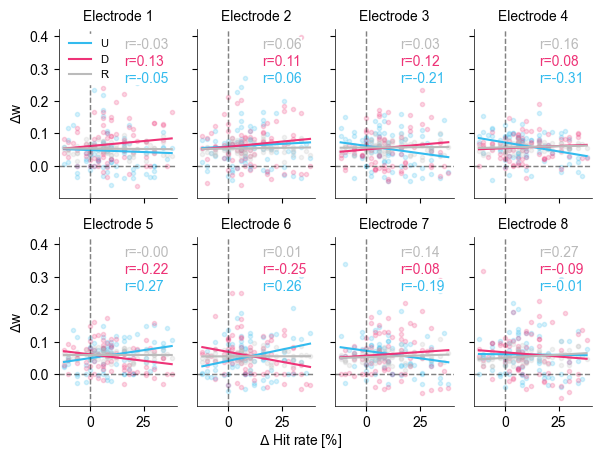

In [27]:
plt.style.use(['nature_d'])
fig, axs = plt.subplots(2, N_ELECTRODES // 2, sharex=True, sharey=True)

for i, ax in enumerate(axs.flatten()):
    
    for j, post_region in enumerate(post_regions):
        
        x = corr_data[:, i, 0] * 100
        y = corr_data[:, i, j+1]
        
        # Set color
        if post_region == "U":
            color = LIGHT_BLUE
        elif post_region == "D":
            color = PINK
        else:
            color = GRAY
            
        ax.axhline(0, color='black', linestyle='--', alpha=0.2)
        ax.axvline(0, color='black', linestyle='--', alpha=0.2)
        
        # Scatter
        ax.scatter(x, y, alpha=0.2, color=color)
        
        # Correlation
        r = np.corrcoef(x, y)[0, 1]
        
        ax.text(
            0.55, 0.75 + j * 0.1,
            f"r={r:.2f}",
            transform=ax.transAxes,
            verticalalignment='top',
            color=color,
            bbox=dict(facecolor="white", edgecolor="none", alpha=1.0, pad=0.2)
        )
        
        # ----- Regression line -----
        slope, intercept = np.polyfit(x, y, 1)
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = slope * x_fit + intercept
        ax.plot(x_fit, y_fit, color=color, linewidth=1.5, label=post_region)
        
        ax.set_title(f"Electrode {i+1}")


fig.text(0.5, 0.01, r'$\Delta$ Hit rate [%]', ha='center', va='center')
axs[0][0].set_ylabel(r'$\Delta$w')
axs[1][0].set_ylabel(r'$\Delta$w')
axs[0][0].legend(frameon=True, facecolor="white", framealpha=1.0, edgecolor="white", loc="upper left")

w, h = fig.get_size_inches()
fig.set_size_inches(w, 4.5)

fig.tight_layout()
if SAVE:
    fig.savefig("output/fig_2_wChangeElectrodes.pdf", dpi=300)
plt.show()

Electrode 4: r = -0.313, 95% CI [-0.498, -0.100], p = 0.038
Electrode 3: r = -0.216, 95% CI [-0.416, 0.004], p = 0.436
Electrode 2: r = -0.038, 95% CI [-0.255, 0.184], p = 5.920
Electrode 1: r = -0.123, 95% CI [-0.334, 0.100], p = 2.220
Electrode 5: r = 0.334, 95% CI [0.123, 0.516], p = 0.020
Electrode 6: r = 0.343, 95% CI [0.133, 0.523], p = 0.015
Electrode 7: r = -0.189, 95% CI [-0.392, 0.032], p = 0.745
Electrode 8: r = 0.054, 95% CI [-0.168, 0.271], p = 5.068


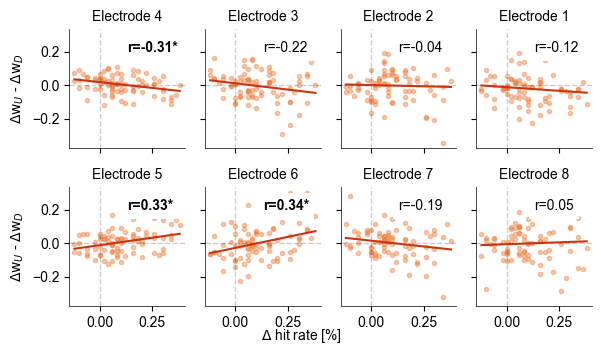

In [30]:

plt.style.use(['nature_d'])
fig, axs = plt.subplots(2, N_ELECTRODES // 2, sharex=True, sharey=True)

for i, ax in enumerate(axs.flatten()):
    
    electrode_plot_order = [3,2,1,0,4,5,6,7]
    electrode_id = electrode_plot_order[i]
    
    for j, (color, d) in enumerate(zip([ORANGE],
                                        [corr_data[:,electrode_id, 1] - corr_data[:,electrode_id, 2]])):
        
        x = corr_data[:, electrode_id, 0]
        y = d 
        ax.scatter(x, y, alpha=0.4, color=color)
        
        # --- Correlation ---
        r, p = pearsonr(x, y)
        n = len(x)
        
        # --- 95% CI using Fisher z transform ---
        z = np.arctanh(r)
        se = 1 / np.sqrt(n - 3)
        z_crit = norm.ppf(0.975)  # two-sided 95%
        z_low = z - z_crit * se
        z_high = z + z_crit * se
        r_low = np.tanh(z_low)
        r_high = np.tanh(z_high)
        
        p = p * N_ELECTRODES
        
        # Format p-value properly
        if p < 0.001:
            p_text = "p < 0.001"
        else:
            p_text = f"p = {p:.3f}"
        
        # Print to console (for paper reporting)
        print(f"Electrode {electrode_id+1}: r = {r:.3f}, 95% CI [{r_low:.3f}, {r_high:.3f}], {p_text}")
        
        # Optional significance stars
        if p < 0.001:
            sig = "***"
        elif p < 0.01:
            sig = "**"
        elif p < 0.05:
            sig = "*"
        else:
            sig = ""
        
        
        # Annotate in plot
        ax.text(
            0.5, 0.9 + j * 0.1,
            f"r={r:.2f}{sig}",
            transform=ax.transAxes,
            verticalalignment='top',
            color='black',
            fontweight='bold' if sig != "" else 'normal',
            bbox=dict(
                facecolor='white',
                edgecolor='none',   # or 'black' if you want a border
                # boxstyle='round,pad=0.2'
            )
        )
        
        ax.axhline(0, color='black', linestyle='--', alpha=0.2)
        ax.axvline(0, color='black', linestyle='--', alpha=0.2)
        
        # Regression line
        slope, intercept = np.polyfit(x, y, 1)
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = slope * x_fit + intercept
        ax.plot(x_fit, y_fit, color=RED, linewidth=1.5)
        
        ax.set_title(f"Electrode {electrode_id + 1}")

fig.text(0.5, 0.025, r'$\Delta$ hit rate [%]', ha='center', va='center')
axs[0][0].set_ylabel(r'$\Delta \text{w}_U$ - $\Delta \text{w}_D$')
axs[1][0].set_ylabel(r'$\Delta \text{w}_U$ - $\Delta \text{w}_D$')

w, h = fig.get_size_inches()
fig.set_size_inches(w, 3.5)

fig.tight_layout()
if True:
    fig.savefig("output/fig_2D_wChangeElectrodeDiff.pdf", dpi=300)

plt.show()